# Module 7 — COVID Quasi-Experiment

**Platform:** REES46 Open CDP — behavioural tracking data from an anonymous multi-category e-commerce retailer operating in the Kazakhstan / CIS market. 411M events, Oct 2019 – Apr 2020.

**Where this fits in the project:** This is the 7th and final analytics module, closing out the series that started with Funnel Analysis (Module 1) and progressed through Session Analytics, RFM Segmentation, Cohort Retention, Category & Brand Performance, and Anomaly Detection (Modules 2–6). Those modules established the platform's normal behavioural baseline — conversion rates, session patterns, customer segments, and known data quality issues (the Feb 27 logging gap, the December 2019 category taxonomy shift). This module uses that baseline to test whether a real external shock — COVID-19 — measurably changed how the platform's customers behaved.

**Business question:** Did the Kazakhstan COVID-19 lockdown (March 16, 2020) measurably change purchasing behaviour on the platform — and if so, was it a shift in *how many* people converted, *how* they browsed, *what* they bought, or *who* was buying?

**Natural experiment setup:** Kazakhstan confirmed its first COVID-19 case on March 13, 2020. A national lockdown began March 16 — an externally imposed, near-instantaneous behavioural shock affecting this platform's entire customer base at once, which creates a clean treatment boundary for causal inference.

| | Pre-COVID | COVID Onset |
|---|---|---|
| **Period** | Oct 1, 2019 – Mar 12, 2020 | Mar 16, 2020 – Apr 30, 2020 |
| **Days** | 163 (excl. Feb 27 logging gap) | 46 |
| **Sessions** | 72,286,478 | 16,262,389 |

**Data quality exclusions (applied in all BigQuery queries, carried over from Module 6):**
- Feb 27, 2020 — confirmed logging gap (z = −18.84, ~90% of events missing)
- Mar 13–15, 2020 — transition window excluded from both groups

**Test:** Two-proportion z-test on *session conversion rate* (purchase sessions / total sessions).  
Session-level conversion is used rather than view-level to ensure statistical independence between observations.

**Scope note:** "Sessions" here means sessions with at least one logged view/cart/purchase event — there is no raw site-visit event in this dataset. All conversion rates in this notebook are measured from first product engagement onward, not from total site traffic. See README Data Quality Findings: "Funnel Floor Bias."

In [10]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Design tokens — dataviz palette.md (reference instance)
C_SURFACE   = '#fcfcfb'
C_PRIMARY   = '#0b0b0b'
C_SECONDARY = '#52514e'
C_MUTED     = '#898781'
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_S1        = '#2a78d6'   # blue  — slot 1, Pre-COVID
C_S2        = '#1baf7a'   # aqua  — slot 2, Returning buyers
C_S6        = '#e34948'   # red   — slot 6, COVID onset
C_GOOD      = '#006300'   # positive delta ink
C_WARN      = '#d03b3b'   # negative/concerning delta ink

plt.rcParams.update({
    'figure.facecolor':  C_SURFACE,
    'axes.facecolor':    C_SURFACE,
    'axes.edgecolor':    C_AXIS,
    'axes.linewidth':    0.8,
    'grid.color':        C_GRID,
    'grid.linewidth':    0.5,
    'text.color':        C_PRIMARY,
    'axes.labelcolor':   C_SECONDARY,
    'xtick.color':       C_MUTED,
    'ytick.color':       C_MUTED,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


---
## 1 — Statistical Test

**H₀:** Session conversion rate is the same in Pre-COVID and COVID-onset periods.  
**H₁:** Session conversion rate is higher during COVID onset (one-tailed — directional hypothesis based on lockdown-driven shift to online purchasing).  

Inputs come directly from the Query 1 BigQuery output.

In [11]:
# Q1 results — session-level metrics
sessions_pre   = 72_286_478
pur_sess_pre   =  4_218_364
sessions_covid = 16_262_389
pur_sess_covid =  1_119_942

# Two-proportion z-test (one-tailed: H1 = COVID conversion > Pre-COVID)
# Implemented manually (pooled-variance formula) — scipy.stats has no
# proportions_ztest (that's a statsmodels function); this pooled-variance
# formula matches statsmodels' default output without adding a dependency.
def two_proportion_ztest(count1, nobs1, count2, nobs2, alternative='larger'):
    p1, p2 = count1 / nobs1, count2 / nobs2
    p_pool = (count1 + count2) / (nobs1 + nobs2)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/nobs1 + 1/nobs2))
    z = (p1 - p2) / se_pool
    if alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z)
    else:
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

z_stat, p_val = two_proportion_ztest(pur_sess_covid, sessions_covid,
                                      pur_sess_pre, sessions_pre,
                                      alternative='larger')

p_pre   = pur_sess_pre   / sessions_pre
p_covid = pur_sess_covid / sessions_covid
delta_pp  = (p_covid - p_pre) * 100
delta_rel = delta_pp / (p_pre * 100) * 100

# 95% CI for the difference (p_covid - p_pre)
se_diff = np.sqrt(p_covid*(1-p_covid)/sessions_covid + p_pre*(1-p_pre)/sessions_pre)
ci_lo   = (p_covid - p_pre - 1.96 * se_diff) * 100
ci_hi   = (p_covid - p_pre + 1.96 * se_diff) * 100

# Cohen's h — effect size for proportions
h = 2 * np.arcsin(np.sqrt(p_covid)) - 2 * np.arcsin(np.sqrt(p_pre))

print('=' * 64)
print('  TWO-PROPORTION Z-TEST — Session Conversion Rate')
print('  H0: p_covid = p_pre  |  H1: p_covid > p_pre  (one-tailed)')
print('=' * 64)
print(f'\n  Pre-COVID    {p_pre*100:.4f}%  ({pur_sess_pre:,} / {sessions_pre:,} sessions)')
print(f'  COVID onset  {p_covid*100:.4f}%  ({pur_sess_covid:,} / {sessions_covid:,} sessions)')
print(f'\n  Delta        +{delta_pp:.4f} pp  (+{delta_rel:.1f}% relative change)')
print(f'  95% CI       [{ci_lo:+.4f} pp,  {ci_hi:+.4f} pp]')
print(f'\n  z-statistic  {z_stat:.2f}')
p_display = f'{p_val:.2e}' if p_val > 1e-300 else '< 1e-300 (effectively 0)'
print(f'  p-value      {p_display}')
print(f'\n  Effect size  Cohen\'s h = {h:.4f}')
print(f'               (small: |h| < 0.2  |  medium: 0.2–0.5  |  large: > 0.5)')
print('=' * 64)
print(f'\n  Verdict: H0 REJECTED — COVID-onset session conversion is')
print(f'  significantly higher than pre-COVID (p << 0.001).')
print(f'\n  Interpretation note: With n = {sessions_pre:,} pre-period sessions,')
print(f'  even a tiny difference is detectable. Cohen\'s h = {h:.4f}')
print(f'  classifies this as a SMALL effect. The difference is real')
print(f'  but modest — +{delta_pp:.2f} pp on a base rate of {p_pre*100:.2f}%.')

  TWO-PROPORTION Z-TEST — Session Conversion Rate
  H0: p_covid = p_pre  |  H1: p_covid > p_pre  (one-tailed)

  Pre-COVID    5.8356%  (4,218,364 / 72,286,478 sessions)
  COVID onset  6.8867%  (1,119,942 / 16,262,389 sessions)

  Delta        +1.0511 pp  (+18.0% relative change)
  95% CI       [+1.0376 pp,  +1.0645 pp]

  z-statistic  160.90
  p-value      < 1e-300 (effectively 0)

  Effect size  Cohen's h = 0.0431
               (small: |h| < 0.2  |  medium: 0.2–0.5  |  large: > 0.5)

  Verdict: H0 REJECTED — COVID-onset session conversion is
  significantly higher than pre-COVID (p << 0.001).

  Interpretation note: With n = 72,286,478 pre-period sessions,
  even a tiny difference is detectable. Cohen's h = 0.0431
  classifies this as a SMALL effect. The difference is real
  but modest — +1.05 pp on a base rate of 5.84%.


---
## 2 — Weekly Session Conversion Rate

Week-by-week session conversion rate across the full dataset window (Oct 2019 – Apr 2020).  
The COVID lockdown boundary (Mar 16) is marked. The Mar 9 week is aggregated (it splits the Pre-COVID / Transition boundary).

> **Note on Feb 10, 2020:** That week shows 527K purchases — 3× the typical weekly volume. The anomaly is in *view-to-purchase* rate (3.65% vs ~1.75% normal), not session conversion (6.14%, within normal range). Likely a Valentine's Day promotion causing repeat purchases within sessions. Feb 10 does not appear as a spike in session conversion and is not annotated on this chart.

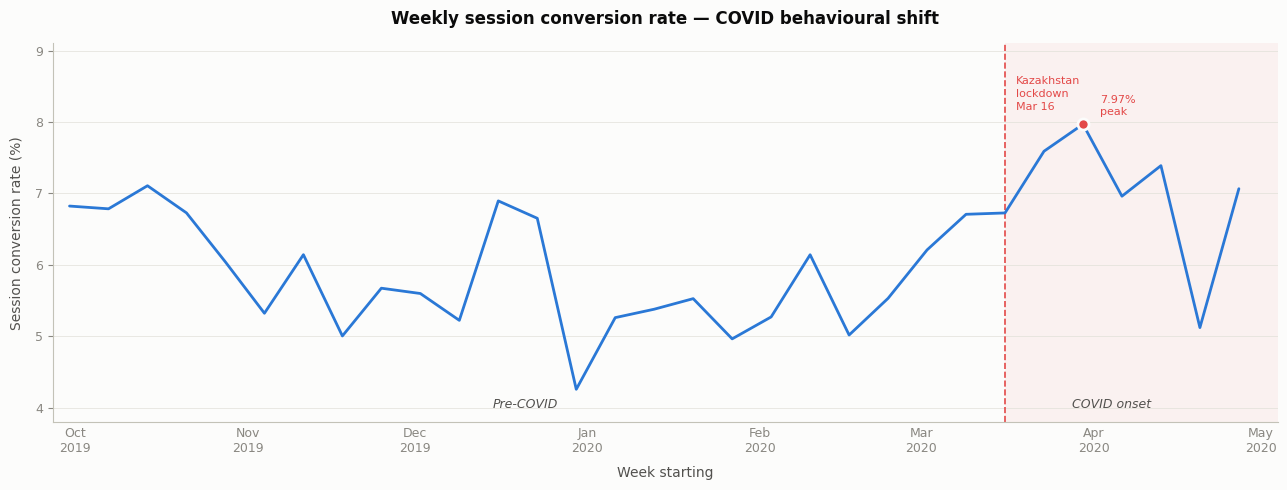

Saved: 07_fig1_weekly_conversion.png


In [12]:
# Q2 data — (week_start, period, weekly_views, weekly_purchases,
#             weekly_sessions, purchase_sessions, v2p_pct, sess_conv_pct)
weekly_raw = [
    ('2019-09-30', 'Pre-COVID',   7333326,  130737, 1615474,  110232, 1.7828, 6.8235),
    ('2019-10-07', 'Pre-COVID',   9505848,  170349, 2131505,  144619, 1.7920, 6.7848),
    ('2019-10-14', 'Pre-COVID',   9877108,  190094, 2264547,  160964, 1.9246, 7.1080),
    ('2019-10-21', 'Pre-COVID',   9270192,  169267, 2132790,  143491, 1.8259, 6.7279),
    ('2019-10-28', 'Pre-COVID',   9236658,  148869, 2110783,  127499, 1.6117, 6.0404),
    ('2019-11-04', 'Pre-COVID',  12244205,  173306, 2801977,  149147, 1.4154, 5.3229),
    ('2019-11-11', 'Pre-COVID',  26154809,  345770, 4665518,  286582, 1.3220, 6.1426),
    ('2019-11-18', 'Pre-COVID',  11169021,  173310, 2923765,  146330, 1.5517, 5.0048),
    ('2019-11-25', 'Pre-COVID',  11252779,  186431, 2789961,  158289, 1.6568, 5.6735),
    ('2019-12-02', 'Pre-COVID',  11302804,  183131, 2740980,  153475, 1.6202, 5.5993),
    ('2019-12-09', 'Pre-COVID',  12112093,  194159, 3093070,  161568, 1.6030, 5.2235),
    ('2019-12-16', 'Pre-COVID',  18063069,  348864, 4192368,  289091, 1.9314, 6.8956),
    ('2019-12-23', 'Pre-COVID',  15899124,  318587, 4003227,  266303, 2.0038, 6.6522),
    ('2019-12-30', 'Pre-COVID',  12292150,  174278, 3412166,  145288, 1.4178, 4.2579),
    ('2020-01-06', 'Pre-COVID',  11371983,  190008, 2996944,  157684, 1.6708, 5.2615),
    ('2020-01-13', 'Pre-COVID',  12556839,  211100, 3244632,  174543, 1.6812, 5.3794),
    ('2020-01-20', 'Pre-COVID',  11740305,  205925, 3072915,  169848, 1.7540, 5.5273),
    ('2020-01-27', 'Pre-COVID',  12643623,  207502, 3501884,  173841, 1.6412, 4.9642),
    ('2020-02-03', 'Pre-COVID',  11588647,  192938, 3049685,  160760, 1.6649, 5.2714),
    ('2020-02-10', 'Pre-COVID',  14460026,  527825, 3663044,  224980, 3.6502, 6.1419),
    ('2020-02-17', 'Pre-COVID',  13256877,  249620, 3524195,  176849, 1.8829, 5.0181),
    ('2020-02-24', 'Pre-COVID',   9321949,  168920, 2528282,  139863, 1.8121, 5.5319),
    ('2020-03-02', 'Pre-COVID',  16474092,  320380, 4301124,  267076, 1.9448, 6.2094),
    ('2020-03-09', 'Transition',  4608512,  106038, 1093470,   89081, 2.3009, 8.1466),  # Mar 13-15
    ('2020-03-09', 'Pre-COVID',   8242784,  158306, 2218121,  133065, 1.9205, 5.9990),  # Mar 9-12
    ('2020-03-16', 'COVID onset', 9023627,  183054, 2258510,  151931, 2.0286, 6.7270),
    ('2020-03-23', 'COVID onset', 9696359,  179097, 1904095,  144537, 1.8471, 7.5909),
    ('2020-03-30', 'COVID onset', 9849492,  181784, 1848625,  147314, 1.8456, 7.9688),
    ('2020-04-06', 'COVID onset',12096093,  192036, 2257070,  157130, 1.5876, 6.9617),
    ('2020-04-13', 'COVID onset',15915430,  270302, 2965403,  219118, 1.6984, 7.3891),
    ('2020-04-20', 'COVID onset',17053187,  204562, 3258441,  166898, 1.1996, 5.1220),
    ('2020-04-27', 'COVID onset', 9970397,  164776, 1889642,  133532, 1.6527, 7.0665),
]

cols = ['week_start', 'period', 'weekly_views', 'weekly_purchases',
        'weekly_sessions', 'purchase_sessions', 'v2p_pct', 'sess_conv_raw']
df_w = pd.DataFrame(weekly_raw, columns=cols)
df_w['week_start'] = pd.to_datetime(df_w['week_start'])

# Aggregate split Mar 9 week (Pre-COVID rows + Transition rows → one combined row)
df_w = (
    df_w.groupby('week_start', as_index=False)
    .agg(weekly_sessions=('weekly_sessions', 'sum'),
         purchase_sessions=('purchase_sessions', 'sum'))
)
df_w['sess_conv_pct'] = df_w['purchase_sessions'] / df_w['weekly_sessions'] * 100
df_w = df_w.sort_values('week_start').reset_index(drop=True)

COVID_START  = pd.Timestamp('2020-03-16')
CHART_END    = pd.Timestamp('2020-05-04')   # one week after last data point
peak_idx     = df_w['sess_conv_pct'].idxmax()
peak_row     = df_w.loc[peak_idx]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(C_SURFACE)

# COVID onset shaded region
ax.axvspan(COVID_START, CHART_END, color=C_S6, alpha=0.06, linewidth=0, zorder=0)

# COVID boundary line
ax.axvline(COVID_START, color=C_S6, linewidth=1.2, linestyle='--', zorder=2)

# Main line — 2px, round caps (marks spec)
ax.plot(df_w['week_start'], df_w['sess_conv_pct'],
        color=C_S1, linewidth=2, zorder=3,
        solid_capstyle='round', solid_joinstyle='round')

# Peak marker — ≥8px (markersize=8), with 2px surface ring
ax.plot(peak_row['week_start'], peak_row['sess_conv_pct'],
        'o', color=C_S6, markersize=8,
        markeredgecolor=C_SURFACE, markeredgewidth=2, zorder=5)
ax.text(peak_row['week_start'] + pd.Timedelta(days=3),
        peak_row['sess_conv_pct'] + 0.10,
        f"{peak_row['sess_conv_pct']:.2f}%\npeak",
        fontsize=8, color=C_S6, va='bottom', ha='left', linespacing=1.3)

# COVID boundary label — placed near the top of the chart, clear of the line itself
ax.text(COVID_START + pd.Timedelta(days=2), 8.65,
        'Kazakhstan\nlockdown\nMar 16',
        fontsize=8, color=C_S6, va='top', ha='left', linespacing=1.4)

# Period labels (text uses secondary ink, not series color)
ax.text(pd.Timestamp('2019-12-15'), 4.0, 'Pre-COVID',
        fontsize=9, color=C_SECONDARY, fontstyle='italic')
ax.text(pd.Timestamp('2020-03-28'), 4.0, 'COVID onset',
        fontsize=9, color=C_SECONDARY, fontstyle='italic')

ax.set_xlim(df_w['week_start'].min() - pd.Timedelta(days=3), CHART_END)
ax.set_ylim(3.8, 9.1)
ax.set_xlabel('Week starting', labelpad=8)
ax.set_ylabel('Session conversion rate (%)', labelpad=8)
ax.set_title('Weekly session conversion rate — COVID behavioural shift',
             fontsize=12, fontweight='bold', pad=14, color=C_PRIMARY)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', length=0)
ax.grid(axis='y', zorder=1)

plt.tight_layout()
plt.savefig('07_fig1_weekly_conversion.png', dpi=150, bbox_inches='tight',
            facecolor=C_SURFACE)
plt.show()
print('Saved: 07_fig1_weekly_conversion.png')

---
## 3 — Session Behaviour Shift

How did per-session behaviour change during COVID onset? Four metrics, indexed against the pre-COVID baseline (= 100).

The mix of units (count, %, dollars) makes a direct comparison invalid — indexing to 100 puts all metrics on a common scale showing direction and magnitude of change.

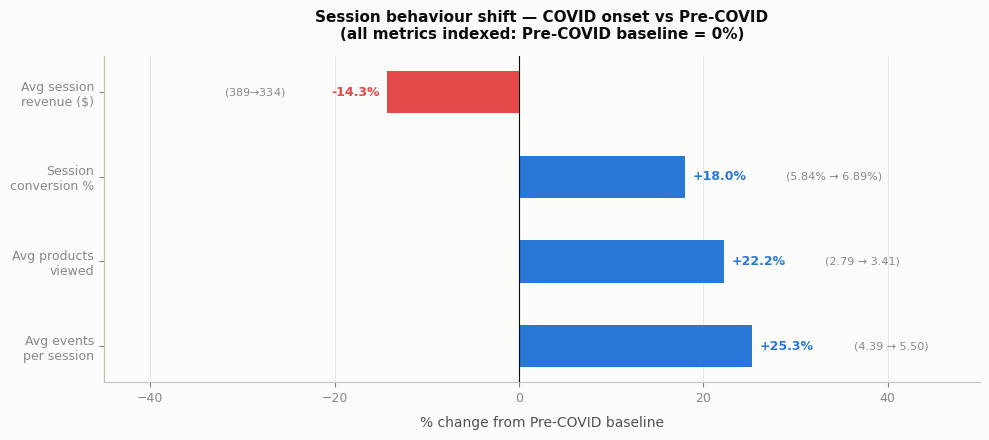

Saved: 07_fig2_session_behavior.png

Interpretation: Sessions got longer (+25%) and broader (+22% products) during
lockdown. More sessions converted to purchases (+18%). But each purchasing
session generated 14% less revenue — people bought cheaper items.


In [13]:
# Q4 data
session_metrics = {
    'Avg events\nper session':   (4.39,   5.50),
    'Avg products\nviewed':      (2.79,   3.41),
    'Session\nconversion %':     (5.8356, 6.8867),
    'Avg session\nrevenue ($)':  (389.23, 333.68),
}

labels    = list(session_metrics.keys())
pre_vals  = [v[0] for v in session_metrics.values()]
covid_vals= [v[1] for v in session_metrics.values()]
pct_changes = [(c - p) / p * 100 for p, c in session_metrics.values()]

# Format value annotations (actual values)
value_annots = [
    ('4.39', '5.50'),
    ('2.79', '3.41'),
    ('5.84%', '6.89%'),
    ('$389', '$334'),
]

bar_colors = [C_S1 if ch > 0 else C_S6 for ch in pct_changes]

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(C_SURFACE)

bars = ax.barh(labels, pct_changes, color=bar_colors,
               linewidth=0, height=0.5, zorder=3)

# Baseline at 0
ax.axvline(0, color=C_PRIMARY, linewidth=0.8, zorder=4)

# Value labels beside each bar (actual pre → covid values)
# Gap between the bold % label and the secondary (pre → covid) label is wide
# enough that a 6-character bold string never runs into the next label.
for i, (ch, (pre_str, covid_str)) in enumerate(zip(pct_changes, value_annots)):
    sign = '+' if ch > 0 else ''
    # Pct change label at bar tip
    x_tip = ch + (0.8 if ch > 0 else -0.8)
    ha    = 'left' if ch > 0 else 'right'
    ax.text(x_tip, i, f'{sign}{ch:.1f}%',
            va='center', ha=ha, fontsize=9, fontweight='bold',
            color=bar_colors[i])
    # Actual values as secondary label — pushed well clear of the bold label
    x2 = ch + (11 if ch > 0 else -11)
    ax.text(x2, i, f'({pre_str} → {covid_str})',
            va='center', ha=ha, fontsize=8, color=C_MUTED)

ax.set_xlabel('% change from Pre-COVID baseline', labelpad=8)
ax.set_title('Session behaviour shift — COVID onset vs Pre-COVID\n'
             '(all metrics indexed: Pre-COVID baseline = 0%)',
             fontsize=11, fontweight='bold', pad=12, color=C_PRIMARY)
ax.set_xlim(-45, 50)
ax.grid(axis='x', zorder=1)

plt.tight_layout()
plt.savefig('07_fig2_session_behavior.png', dpi=150, bbox_inches='tight',
            facecolor=C_SURFACE)
plt.show()
print('Saved: 07_fig2_session_behavior.png')
print()
print('Interpretation: Sessions got longer (+25%) and broader (+22% products) during')
print('lockdown. More sessions converted to purchases (+18%). But each purchasing')
print('session generated 14% less revenue — people bought cheaper items.')

---
## 4 — Category Revenue Mix Shift

Which categories gained or lost revenue share during COVID onset?

**Baseline window: Jan 1 – Mar 12, 2020** (not Oct 2019) — the Dec 2 taxonomy event caused Apple/Samsung/Xiaomi to be reclassified to `construction`, making any pre-December category comparison unreliable. Using January 2020 as the baseline avoids that confound.

> `DIY / Home Improvement` (raw: `construction`) is **excluded** from this chart. It held 69% pre / 57% COVID share — but this reflects the taxonomy reclassification of smartphones, not genuine DIY behaviour. See README Data Quality section.

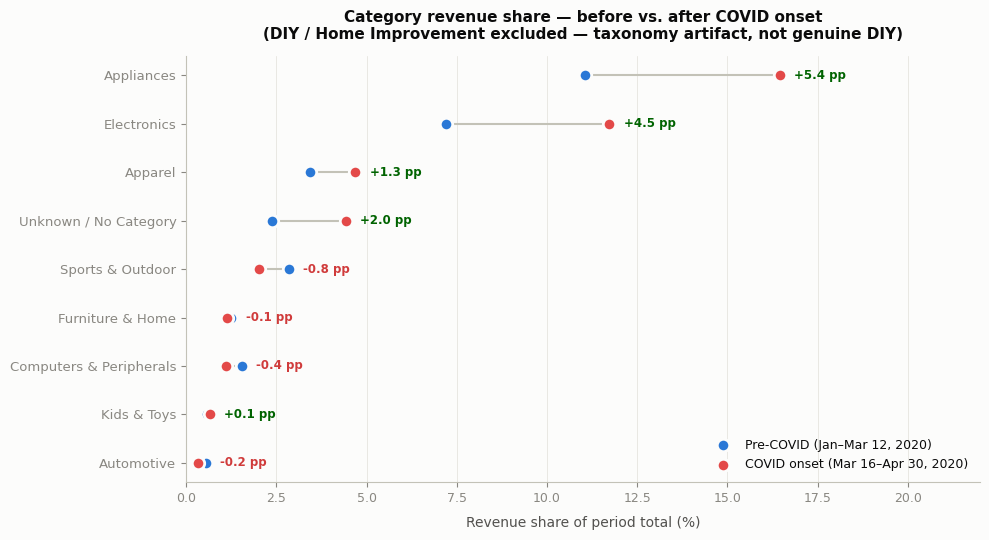

Saved: 07_fig3_category_mix.png


In [14]:
# Q3 data — excluding DIY/Home Improvement (taxonomy artifact)
# (category, pre_share_pct, covid_share_pct)
cat_data = [
    ('Appliances',             11.06, 16.45),
    ('Electronics',             7.19, 11.72),
    ('Apparel',                 3.44,  4.69),
    ('Unknown / No Category',   2.38,  4.43),
    ('Sports & Outdoor',        2.84,  2.01),
    ('Computers & Peripherals', 1.54,  1.11),
    ('Furniture & Home',        1.25,  1.13),
    ('Kids & Toys',             0.57,  0.65),
    ('Automotive',              0.54,  0.34),
]

df_cat = pd.DataFrame(cat_data, columns=['category', 'pre_pct', 'covid_pct'])
df_cat['delta'] = df_cat['covid_pct'] - df_cat['pre_pct']
df_cat = df_cat.sort_values('covid_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(C_SURFACE)

y = range(len(df_cat))

# Dumbbell connecting lines (in axis color — not data-colored)
for i, row in enumerate(df_cat.itertuples()):
    ax.hlines(i, row.pre_pct, row.covid_pct,
              color=C_AXIS, linewidth=1.5, zorder=2)

# Pre-COVID dots — slot 1 blue, 2px surface ring
ax.scatter(df_cat['pre_pct'], list(y),
           s=80, color=C_S1, zorder=4,
           edgecolors=C_SURFACE, linewidths=2,
           label='Pre-COVID (Jan–Mar 12, 2020)')

# COVID onset dots — slot 6 red, 2px surface ring
ax.scatter(df_cat['covid_pct'], list(y),
           s=80, color=C_S6, zorder=4,
           edgecolors=C_SURFACE, linewidths=2,
           label='COVID onset (Mar 16–Apr 30, 2020)')

# Category labels on y-axis
ax.set_yticks(list(y))
ax.set_yticklabels(df_cat['category'], fontsize=9.5)

# Delta label at right — secondary ink, not series color (per mark spec)
for i, row in enumerate(df_cat.itertuples()):
    sign  = '+' if row.delta > 0 else ''
    ink   = C_GOOD if row.delta > 0 else C_WARN
    x_tip = max(row.pre_pct, row.covid_pct) + 0.4
    ax.text(x_tip, i, f'{sign}{row.delta:.1f} pp',
            va='center', ha='left', fontsize=8.5,
            color=ink, fontweight='bold')

ax.set_xlabel('Revenue share of period total (%)', labelpad=8)
ax.set_title('Category revenue share — before vs. after COVID onset\n'
             '(DIY / Home Improvement excluded — taxonomy artifact, not genuine DIY)',
             fontsize=11, fontweight='bold', pad=12, color=C_PRIMARY)
ax.set_xlim(0, 22)
ax.grid(axis='x', zorder=1)
ax.legend(fontsize=9, framealpha=0, loc='lower right')

plt.tight_layout()
plt.savefig('07_fig3_category_mix.png', dpi=150, bbox_inches='tight',
            facecolor=C_SURFACE)
plt.show()
print('Saved: 07_fig3_category_mix.png')

---
## 5 — New vs Returning Buyer Mix

A 'new buyer' is a user whose *first-ever purchase* fell within the given period.  
A 'returning buyer' had at least one prior purchase before the period started.

**Key question:** Did COVID bring new users to e-commerce, or activate existing customers?

Raw buyer counts are not comparable across periods (different period lengths).  
The stacked bar shows *composition* (% split); the annotation shows *daily rate* to normalise for period length.

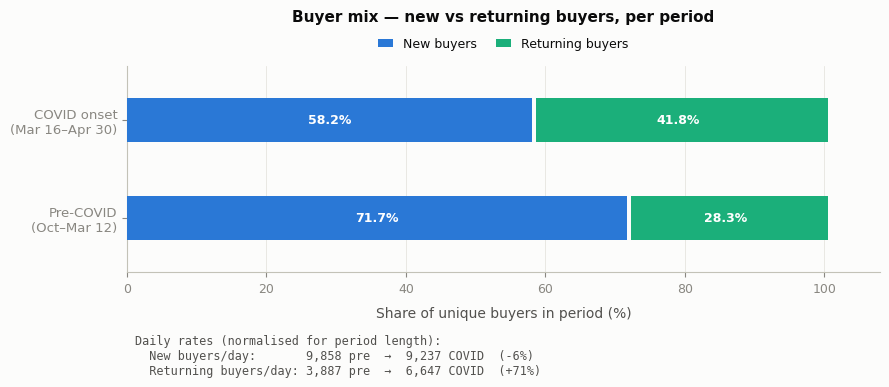

Saved: 07_fig4_buyer_mix.png

New buyer daily rate:       -6% (roughly flat)
Returning buyer daily rate: +71% surge during COVID
COVID was a retention catalyst, not a new-user acquisition driver.


In [15]:
# Q5 data
new_pre     = 1_606_920
ret_pre     = 633_585
new_covid   = 424_885
ret_covid   = 305_779
days_pre    = 163
days_covid  = 46

total_pre   = new_pre + ret_pre
total_covid = new_covid + ret_covid

new_pct_pre   = new_pre   / total_pre   * 100
ret_pct_pre   = ret_pre   / total_pre   * 100
new_pct_covid = new_covid / total_covid * 100
ret_pct_covid = ret_covid / total_covid * 100

# Daily rates (normalised for period length)
new_daily_pre   = new_pre   / days_pre
ret_daily_pre   = ret_pre   / days_pre
new_daily_covid = new_covid / days_covid
ret_daily_covid = ret_covid / days_covid
ret_daily_change = (ret_daily_covid - ret_daily_pre) / ret_daily_pre * 100
new_daily_change = (new_daily_covid - new_daily_pre) / new_daily_pre * 100

periods     = ['Pre-COVID\n(Oct–Mar 12)', 'COVID onset\n(Mar 16–Apr 30)']
new_pcts    = [new_pct_pre,   new_pct_covid]
ret_pcts    = [ret_pct_pre,   ret_pct_covid]

fig, ax = plt.subplots(figsize=(9, 4.3))
fig.patch.set_facecolor(C_SURFACE)

bar_h = 0.45
y = [0, 1]

# Stacked bars — 2px surface gap via edgecolor
b1 = ax.barh(y, new_pcts, height=bar_h, color=C_S1, label='New buyers',
             linewidth=0, zorder=3)
b2 = ax.barh(y, ret_pcts, height=bar_h, left=new_pcts, color=C_S2,
             label='Returning buyers', linewidth=0, zorder=3)

# 2px surface gap between stacked segments
for bar in b2:
    bar.set_x(bar.get_x() + 0.5)

# Value labels inside bars (only if wide enough — both segments are wide here)
for i, (np_, rp) in enumerate(zip(new_pcts, ret_pcts)):
    if np_ > 8:
        ax.text(np_/2, i, f'{np_:.1f}%', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')
    if rp > 8:
        ax.text(np_ + rp/2, i, f'{rp:.1f}%', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(periods, fontsize=9.5)
ax.set_xlabel('Share of unique buyers in period (%)', labelpad=8)
ax.set_title('Buyer mix — new vs returning buyers, per period',
             fontsize=11, fontweight='bold', pad=32, color=C_PRIMARY)
ax.set_xlim(0, 108)
ax.set_ylim(-0.55, 1.55)  # headroom above/below bars so nothing touches the legend or annotation
# Legend placed fully above the axes (outside the plot area) so it never
# overlaps the top bar — previously loc='upper right' sat directly on it.
ax.legend(fontsize=9, framealpha=0, loc='lower center',
          bbox_to_anchor=(0.5, 1.02), ncol=2, handlelength=1.2, columnspacing=1.5)
ax.grid(axis='x', zorder=1)

# Daily rate annotation box
annot = (
    f'Daily rates (normalised for period length):\n'
    f'  New buyers/day:       {new_daily_pre:,.0f} pre  →  {new_daily_covid:,.0f} COVID  '
    f'({new_daily_change:+.0f}%)\n'
    f'  Returning buyers/day: {ret_daily_pre:,.0f} pre  →  {ret_daily_covid:,.0f} COVID  '
    f'({ret_daily_change:+.0f}%)'
)
ax.text(0.01, -0.30, annot, transform=ax.transAxes,
        fontsize=8.5, color=C_SECONDARY, va='top',
        fontfamily='monospace')

plt.tight_layout()
plt.subplots_adjust(bottom=0.30, top=0.78)
plt.savefig('07_fig4_buyer_mix.png', dpi=150, bbox_inches='tight',
            facecolor=C_SURFACE)
plt.show()
print('Saved: 07_fig4_buyer_mix.png')
print()
print(f'New buyer daily rate:       {new_daily_change:+.0f}% (roughly flat)')
print(f'Returning buyer daily rate: {ret_daily_change:+.0f}% surge during COVID')
print('COVID was a retention catalyst, not a new-user acquisition driver.')

---
## Summary of Findings

| Finding | Pre-COVID | COVID onset | Δ |
|---|---|---|---|
| Session conversion rate | 5.84% | 6.89% | **+1.05 pp (+18%)** |
| z-statistic | — | — | ~161 (p << 0.001) |
| Cohen's h (effect size) | — | — | ~0.044 (small) |
| Avg order value (AOV) | `$307.49` | `$271.67` | **−11.7%** |
| Avg events per session | 4.39 | 5.50 | **+25%** |
| Avg products viewed | 2.79 | 3.41 | **+22%** |
| Avg session revenue | `$389.23` | `$333.68` | **−14%** |
| Returning buyer daily rate | 3,887/day | 6,648/day | **+71%** |
| New buyer daily rate | 9,858/day | 9,236/day | −6% (roughly flat) |

**1. The conversion increase is statistically significant but practically small.**  
z = ~161, p << 0.001 — H₀ is firmly rejected. But Cohen's h ≈ 0.044 is a *small* effect. With 72M+ pre-COVID sessions in the sample, even a trivial difference is detectable. The shift is real, but the magnitude is modest (+1.05 pp).

**2. The view-to-purchase paradox is methodologically important.**  
View-level conversion *fell* (1.80% → 1.65%) while session-level conversion *rose* (5.84% → 6.89%). People browsed 22% more products per session during lockdown. More views per session dilutes the view-level rate even though more sessions ended in purchase. Always choose the right denominator.

**3. Economic caution during lockdown.**  
Avg session revenue fell 14% and AOV fell 11.7% — consistently across both new and returning buyers. People were engaged but bought cheaper items. Lockdown drove engagement, not spending power.

**4. COVID was a retention catalyst, not an acquisition driver.**  
Returning buyer daily rate surged +71%. New buyer acquisition was roughly flat (−6%). Existing customers returned more often. CRM and loyalty programs would have had the highest impact during this period.

**5. Category winners: Appliances (+5.4 pp) and Electronics (+4.5 pp). Loser: Sports & Outdoor (−0.8 pp).**  
Home investment patterns dominated during lockdown. Active outdoor categories contracted. All category-level interpretation carries the `construction` taxonomy caveat (see README).

**6. Conversion peak was March 30, 2020 (7.97%) — two weeks into the lockdown.**  
The behavioural shift was immediate at lockdown onset (Mar 16 → 6.73%) and peaked at Mar 30 (7.97%). By late April it had partially reverted to 5.12% (lockdown fatigue / restrictions easing). The shock was sharp and fast.